# 🧠 Bipolar Phase Monitor — Fusion CNN (Tachyphémie) + Wav2Vec2 (Émotion)

Ce notebook fusionne deux modules d'analyse vocale pour estimer la **phase bipolaire** du patient :

| Module | Modèle | Sortie |
|---|---|---|
| **Tachyphémie** | CNN sur spectrogrammes Mel | `normal / tachyphemia` + débit (syl/s) + score agitation |
| **Émotion** | Wav2Vec2 fine-tuné (RAVDESS/CREMA/TESS/SAVEE) | `happy / sad / angry / neutral` + probabilités |
| **Fusion** | Règles cliniques fondées sur la littérature | `maniaque / hypomaniaque / dépressif / neutre` |

---

### 🔬 Base scientifique de la fusion

D'après : Faurholt-Jepsen et al. (2016), Kaczmarek-Majer et al. (2025), CALIBER Study (2024) :

| Phase | Tachyphémie | Émotion vocale | Débit de parole |
|---|---|---|---|
| **Maniaque** | Oui (fort) | angry / happy | > 5.5 syl/s |
| **Hypomaniaque** | Oui (modéré) | happy / neutral-positif | 4–5.5 syl/s |
| **Dépressif** | Non (lent) | sad / neutral | < 3 syl/s |
| **Neutre** | Non | neutral | 3–5 syl/s |

> ⚠️ **Note éthique** : outil de monitoring NON-DIAGNOSTIQUE. Ne remplace pas un avis médical.

In [36]:
# ============================================================
# 1. INSTALLATIONS (décommenter si nécessaire)
# ============================================================
# !pip install librosa tensorflow scikit-learn transformers torch \
#              matplotlib seaborn soundfile numpy pandas tqdm opencv-python-headless

In [37]:
# ============================================================
# 2. IMPORTS
# ============================================================
import os, warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

warnings.filterwarnings("ignore")
tf.random.set_seed(42); np.random.seed(42)
print("TF:", tf.__version__, "| PyTorch:", torch.__version__)
print("GPU TF:", tf.config.list_physical_devices('GPU'))
print("GPU Torch:", torch.cuda.is_available())

TF: 2.20.0 | PyTorch: 2.6.0+cu124
GPU TF: []
GPU Torch: True


In [38]:
# ============================================================
# 3. CONFIGURATION GLOBALE
# ============================================================

# --- Chemins datasets ---
RAVDESS_DIR  = Path("C:/Users/LOQ/Desktop/testpi/DATASETS/RAVDESS/Audio_Speech_Actors_01-24")
CREMA_PATH   = Path("C:/Users/LOQ/Desktop/testpi/DATASETS/CREMA")
TESS_PATH    = Path("C:/Users/LOQ/Desktop/testpi/DATASETS/Tess")
SAVEE_PATH   = Path("C:/Users/LOQ/Desktop/testpi/DATASETS/SAVEE")
BD_AUDIO_DIR = Path("C:/Users/LOQ/Desktop/testpi/DATASETS/BD-Audio")

# --- Chemins modèles sauvegardés ---
TACHY_MODEL_PATH   = Path("tachyphemia_cnn_final.keras")
EMOTION_MODEL_PATH = Path("outputs/wav2vec2-emotion")

# --- Spectrogramme (CNN) ---
SAMPLE_RATE = 22050; DURATION = 3.0
N_MELS = 128; N_FFT = 2048; HOP_LENGTH = 512
IMG_HEIGHT = 128; IMG_WIDTH = 128

# --- Seuils cliniques (Faurholt-Jepsen 2016, CALIBER 2024) ---
SPEECH_RATE_SLOW   = 3.0   # < 3 syl/s  → ralentissement (dépressif)
SPEECH_RATE_FAST   = 5.5   # > 5.5 syl/s → accélération (maniaque)
AGITATION_HIGH     = 0.65  # score agitation élevé
AGITATION_MODERATE = 0.40  # score agitation modéré

# --- Labels émotion ---
EMOTION_LABELS = ["happy", "sad", "angry", "neutral"]
TARGET_SR_EMOTION = 16000   # Wav2Vec2 attend 16 kHz

# Couleurs par phase finale
PHASE_COLORS = {
    "MANIAQUE": "#e74c3c",
    "HYPOMANIAQUE": "#e67e22",
    "DEPRESSIF": "#2980b9",
    "NEUTRE": "#27ae60",
}

print("Configuration chargée.")

Configuration chargée.


---
## PARTIE A — Module Tachyphémie (CNN)
*Repris depuis tachyphemia_detector.ipynb*

In [39]:
# ============================================================
# 4. SPECTROGRAMME MEL
# ============================================================
def compute_mel_spectrogram(file_path):
    import cv2
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        tl = int(SAMPLE_RATE * DURATION)
        y = np.pad(y, (0, max(0, tl - len(y))))[:tl]
        peak = np.max(np.abs(y))
        if peak > 0: y /= peak
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mn, mx = mel_db.min(), mel_db.max()
        mel_norm = (mel_db - mn) / (mx - mn + 1e-9)
        mel_r = cv2.resize(mel_norm, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_LINEAR)
        return mel_r[..., np.newaxis].astype(np.float32)
    except Exception as e:
        print(f"Erreur spectrogramme {file_path}: {e}")
        return None

print("compute_mel_spectrogram() définie.")

compute_mel_spectrogram() définie.


In [40]:
# ============================================================
# 5. CHARGEMENT DATASET TACHYPHÉMIE
# ============================================================
RAVDESS_EMO_MAP = {"01":"neutral","02":"calm","03":"happy","04":"sad",
                   "05":"angry","06":"fearful","07":"disgust","08":"surprised"}
TACHY_PROXY  = {"angry","happy","surprised"}
NORMAL_PROXY = {"neutral","calm","sad"}

def load_tachy_dataset():
    X, y, fps = [], [], []
    if BD_AUDIO_DIR.exists():
        for lname, lint in [("normal",0),("tachyphemia",1)]:
            for wav in sorted((BD_AUDIO_DIR/lname).glob("*.wav")):
                s = compute_mel_spectrogram(wav)
                if s is not None: X.append(s); y.append(lint); fps.append(str(wav))
        src = "BD-Audio"
    else:
        print("BD-Audio absent → RAVDESS fallback")
        for d in sorted(RAVDESS_DIR.glob("Actor_*")):
            for wav in sorted(d.glob("*.wav")):
                parts = wav.name.split("-")
                emo = RAVDESS_EMO_MAP.get(parts[2] if len(parts)>2 else "")
                if emo in TACHY_PROXY:   lint = 1
                elif emo in NORMAL_PROXY: lint = 0
                else: continue
                s = compute_mel_spectrogram(wav)
                if s is not None: X.append(s); y.append(lint); fps.append(str(wav))
        src = "RAVDESS (simulation)"
    X = np.array(X, dtype=np.float32); y = np.array(y, dtype=np.int32)
    print(f"Tachyphémie ({src}): {len(X)} samples — normal={np.sum(y==0)} | tachy={np.sum(y==1)}")
    return X, y, fps

X_tachy, y_tachy, fps_tachy = load_tachy_dataset()

BD-Audio absent → RAVDESS fallback
Tachyphémie (RAVDESS (simulation)): 1056 samples — normal=480 | tachy=576


In [41]:
# ============================================================
# 6. CNN TACHYPHÉMIE — CHARGEMENT OU ENTRAÎNEMENT
# ============================================================
def build_cnn():
    inp = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1))
    x = inp
    for f in [32, 64, 128]:
        for _ in range(2):
            x = layers.Conv2D(f, 3, padding="same")(x)
            x = layers.BatchNormalization()(x)
            x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

if TACHY_MODEL_PATH.exists():
    print(f"Chargement CNN : {TACHY_MODEL_PATH}")
    cnn_model = keras.models.load_model(TACHY_MODEL_PATH)
else:
    print("Entraînement CNN tachyphémie...")
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_tachy, y_tachy, test_size=0.15, stratify=y_tachy, random_state=42)
    cnn_model = build_cnn()
    cnn_model.fit(X_tr, y_tr, validation_split=0.15, epochs=30, batch_size=32,
                  callbacks=[callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
                  verbose=1)
    cnn_model.save("tachyphemia_cnn_final.keras")
    print("CNN sauvegardé.")
print("CNN prêt.")

Chargement CNN : tachyphemia_cnn_final.keras
CNN prêt.


In [42]:
# ============================================================
# 7. PRÉDICTION TACHYPHÉMIE
# ============================================================
def predict_tachyphemia(file_path):
    spec = compute_mel_spectrogram(file_path)
    if spec is None: return {"error": "spectrogramme invalide"}
    prob = float(cnn_model.predict(np.expand_dims(spec,0), verbose=0)[0,0])
    label = "tachyphemia" if prob >= 0.5 else "normal"
    try:
        y_raw, sr_ = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        oe = librosa.onset.onset_strength(y=y_raw, sr=sr_, hop_length=HOP_LENGTH)
        tempo_bpm = float(librosa.feature.rhythm.tempo(onset_envelope=oe, sr=sr_, hop_length=HOP_LENGTH)[0])
        speech_rate = tempo_bpm / 14.0
    except:
        tempo_bpm = speech_rate = 0.0
    agitation = round(0.6*prob + 0.4*min(speech_rate/8.0, 1.0), 4)
    return {"file": str(file_path), "cnn_label": label, "cnn_probability": round(prob,4),
            "tempo_bpm": round(tempo_bpm,1), "speech_rate_syl_per_sec": round(speech_rate,2),
            "agitation_score": agitation}

print("predict_tachyphemia() définie.")

predict_tachyphemia() définie.


---
## PARTIE B — Module Émotion (Wav2Vec2)
*Repris depuis multidataset_emotion.ipynb*

In [43]:
# ============================================================
# 8. CHARGEMENT DATASET ÉMOTION (multi-dataset)
# ============================================================
CREMA_MAP   = {"ANG":"angry","HAP":"happy","SAD":"sad","NEU":"neutral"}
RAVDESS_MAP = {"01":"neutral","03":"happy","04":"sad","05":"angry"}
SAVEE_MAP   = {"a":"angry","h":"happy","sa":"sad","n":"neutral"}
TARGET_EMO  = ["happy","sad","angry","neutral"]

def parse_crema(p):
    rows=[]
    if not p.exists(): return pd.DataFrame()
    for w in tqdm(list(p.rglob("*.wav")), desc="CREMA"):
        pts=w.stem.split("_")
        if len(pts)<3: continue
        e=CREMA_MAP.get(pts[2])
        if e: rows.append({"file_path":str(w),"emotion":e,"speaker":pts[0]})
    return pd.DataFrame(rows)

def parse_ravdess(p):
    rows=[]
    if not p.exists(): return pd.DataFrame()
    for w in tqdm(list(p.rglob("*.wav")), desc="RAVDESS"):
        pts=w.stem.split("-")
        if len(pts)<7: continue
        e=RAVDESS_MAP.get(pts[2])
        if e: rows.append({"file_path":str(w),"emotion":e,"speaker":pts[-1]})
    return pd.DataFrame(rows)

def parse_tess(p):
    rows=[]
    if not p.exists(): return pd.DataFrame()
    for w in tqdm(list(p.rglob("*.wav")), desc="TESS"):
        e=next((x for x in TARGET_EMO if x in w.name.lower() or x in str(w.parent).lower()),None)
        if e: rows.append({"file_path":str(w),"emotion":e,"speaker":"unknown"})
    return pd.DataFrame(rows)

def parse_savee(p):
    rows=[]
    if not p.exists(): return pd.DataFrame()
    for w in tqdm(list(p.rglob("*.wav")), desc="SAVEE"):
        if "_" not in w.stem: continue
        spk,code=w.stem.split("_",1)
        k="sa" if code.startswith("sa") else code[0]
        e=SAVEE_MAP.get(k)
        if e: rows.append({"file_path":str(w),"emotion":e,"speaker":spk})
    return pd.DataFrame(rows)

df_all = pd.concat([parse_crema(CREMA_PATH), parse_ravdess(RAVDESS_DIR),
                    parse_tess(TESS_PATH), parse_savee(SAVEE_PATH)], ignore_index=True)
df_all = df_all[df_all["emotion"].isin(TARGET_EMO)].reset_index(drop=True)
print(f"Total émotion : {len(df_all):,}")
print(df_all["emotion"].value_counts())

SAVEE: 100%|██████████| 480/480 [00:00<00:00, 480149.28it/s]

Total émotion : 7,472
emotion
angry      1923
happy      1923
sad        1923
neutral    1703
Name: count, dtype: int64


In [44]:
# ============================================================
# 9. CHARGEMENT / ENTRAÎNEMENT MODÈLE ÉMOTION
# ============================================================
from torch.utils.data import Dataset
from transformers import Trainer, TrainingArguments

LABELS   = TARGET_EMO
label2id = {l:i for i,l in enumerate(LABELS)}
id2label = {i:l for l,i in label2id.items()}

def load_audio_fixed(path, sr=TARGET_SR_EMOTION, dur=3.0):
    y, _ = librosa.load(path, sr=sr, duration=dur)
    t = int(sr*dur)
    return np.pad(y,(0,max(0,t-len(y))))[:t].astype(np.float32)

class EmotionDS(Dataset):
    def __init__(self,df,proc):
        self.df=df.reset_index(drop=True); self.proc=proc
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]; a=load_audio_fixed(r["file_path"])
        inp=self.proc(a,sampling_rate=TARGET_SR_EMOTION,return_tensors="pt")
        return {"input_values":inp.input_values.squeeze(0),
                "labels":torch.tensor(label2id[r["emotion"]],dtype=torch.long)}

def resolve_emotion_model_path(base_path):
    root_processor = base_path / 'preprocessor_config.json'
    root_model = base_path / 'config.json'
    if root_processor.exists() and root_model.exists():
        return base_path
    checkpoints = sorted(
        [p for p in base_path.glob('checkpoint-*') if p.is_dir()],
        key=lambda p: int(p.name.split('-')[-1]) if p.name.split('-')[-1].isdigit() else -1
    )
    if checkpoints:
        return checkpoints[-1]
    return None

if EMOTION_MODEL_PATH.exists():
    resolved_emotion_path = resolve_emotion_model_path(EMOTION_MODEL_PATH)
    if resolved_emotion_path is not None:
        print(f"Chargement modèle émotion : {resolved_emotion_path}")
        try:
            emotion_processor = Wav2Vec2Processor.from_pretrained(str(resolved_emotion_path))
            emotion_model = Wav2Vec2ForSequenceClassification.from_pretrained(str(resolved_emotion_path))
            emotion_model.eval()
        except OSError as exc:
            print(f"[WARN] Chargement local impossible ({exc}); fallback vers facebook/wav2vec2-base.")
            emotion_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
            emotion_model = Wav2Vec2ForSequenceClassification.from_pretrained("facebook/wav2vec2-base", num_labels=len(LABELS), label2id=label2id, id2label=id2label)
            emotion_model.eval()
    else:
        print("[WARN] Aucun checkpoint émotion trouvé → fallback vers facebook/wav2vec2-base.")
        emotion_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
        emotion_model = Wav2Vec2ForSequenceClassification.from_pretrained("facebook/wav2vec2-base", num_labels=len(LABELS), label2id=label2id, id2label=id2label)
        emotion_model.eval()
else:
    print("Entraînement Wav2Vec2 émotion...")
    from sklearn.model_selection import GroupShuffleSplit
    mc = df_all["emotion"].value_counts().min()
    df_bal = (df_all.groupby("emotion",group_keys=False)
              .apply(lambda x:x.sample(mc,random_state=42)).reset_index(drop=True))
    gss = GroupShuffleSplit(n_splits=1,test_size=0.15,random_state=42)
    tr,te = next(gss.split(df_bal,groups=df_bal["speaker"]))
    emotion_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
    emotion_model = Wav2Vec2ForSequenceClassification.from_pretrained(
        "facebook/wav2vec2-base", num_labels=len(LABELS), label2id=label2id, id2label=id2label)
    def cm(ep):
        p=np.argmax(ep.predictions,axis=1)
        return {"accuracy":accuracy_score(ep.label_ids,p),
                "macro_f1":f1_score(ep.label_ids,p,average="macro")}
    trainer = Trainer(model=emotion_model,
        args=TrainingArguments(output_dir=str(EMOTION_MODEL_PATH),
            per_device_train_batch_size=4, num_train_epochs=3, learning_rate=2e-5,
            evaluation_strategy="epoch", save_strategy="epoch",
            fp16=torch.cuda.is_available(), report_to="none"),
        train_dataset=EmotionDS(df_bal.iloc[tr],emotion_processor),
        eval_dataset=EmotionDS(df_bal.iloc[te],emotion_processor),
        tokenizer=emotion_processor, compute_metrics=cm)
    trainer.train()
    emotion_model.eval()
    emotion_model.save_pretrained(str(EMOTION_MODEL_PATH))
    emotion_processor.save_pretrained(str(EMOTION_MODEL_PATH))
    print("Wav2Vec2 entraîné et sauvegardé.")
print("Modèle émotion prêt.")

Chargement modèle émotion : outputs\wav2vec2-emotion\checkpoint-4221
Modèle émotion prêt.


In [45]:
# ============================================================
# 10. PRÉDICTION ÉMOTION
# ============================================================
def predict_emotion(file_path):
    try:
        audio  = load_audio_fixed(file_path)
        device = next(emotion_model.parameters()).device
        inp    = emotion_processor(audio, sampling_rate=TARGET_SR_EMOTION, return_tensors="pt")
        with torch.no_grad():
            logits = emotion_model(inp.input_values.to(device)).logits
        probs  = torch.nn.functional.softmax(logits,dim=-1).cpu().numpy()[0]
        pred   = int(np.argmax(probs))
        return {"emotion": LABELS[pred],
                "probabilities": {LABELS[i]:round(float(probs[i]),4) for i in range(len(LABELS))},
                "confidence": round(float(probs[pred]),4)}
    except Exception as e:
        return {"error":str(e),"emotion":"neutral","probabilities":{},"confidence":0.0}

print("predict_emotion() définie.")

predict_emotion() définie.


---
## PARTIE C — Moteur de Fusion : Phase Bipolaire

### Tableau de fusion scientifique complet

| Tachyphémie (score) | Émotion | Débit (syl/s) | Phase estimée | Références |
|---|---|---|---|---|
| Fort ≥0.65 | angry ou happy | > 5.5 | **MANIAQUE** | YMRS item 6 ; Faurholt-Jepsen 2016 |
| Modéré–fort | happy / angry / neutral | 4–5.5 | **HYPOMANIAQUE** | CALIBER 2024 ; Kaczmarek-Majer 2025 |
| Absent ou faible | sad | < 3 | **DEPRESSIF** | HAMD item 8 ; Frontiers 2024 |
| Absent | neutral | 3–5.5 | **NEUTRE** | Faurholt-Jepsen 2016 |

In [46]:
# ============================================================
# 11. MOTEUR DE FUSION — RÈGLES CLINIQUES
# ============================================================
def determine_bipolar_phase(tachy: dict, emo: dict) -> dict:
    """
    Fusionne CNN tachyphémie + Wav2Vec2 émotion → phase bipolaire.
    Basé sur : Faurholt-Jepsen 2016, Kaczmarek-Majer 2025, CALIBER 2024,
               Frontiers Neurology 2024, Translational Psychiatry 2021.
    """
    agitation   = tachy.get("agitation_score", 0.0)
    speech_rate = tachy.get("speech_rate_syl_per_sec", 0.0)
    cnn_label   = tachy.get("cnn_label", "normal")
    emotion     = emo.get("emotion", "neutral")
    emo_conf    = emo.get("confidence", 0.0)
    emo_probs   = emo.get("probabilities", {})

    # Catégories débit
    rate_fast   = speech_rate > SPEECH_RATE_FAST
    rate_slow   = speech_rate < SPEECH_RATE_SLOW
    rate_normal = not rate_fast and not rate_slow

    # Catégories agitation
    agit_high = agitation >= AGITATION_HIGH
    agit_mod  = AGITATION_MODERATE <= agitation < AGITATION_HIGH
    agit_low  = agitation < AGITATION_MODERATE

    # Probabilités utiles
    p_sad   = emo_probs.get("sad",   0.0)
    p_angry = emo_probs.get("angry", 0.0)

    PHASE_SCORE = {
        "DEPRESSIF":-2, "DEPRESSIF_LEGER":-1, "EUTHYMIQUE":0,
        "IRRITABILITE_RESIDUELLE":0.5, "HYPOMANIAQUE":1,
        "MANIAQUE":2, "MIXTE":99, "INDETERMINE":None
    }

    # ── Règles ──────────────────────────────────────────────
    if emotion == "sad":
        if rate_slow or agitation < AGITATION_MODERATE or speech_rate < SPEECH_RATE_SLOW:
            phase = "DEPRESSIF"; conf = "élevée"
            expl = "Affect triste + ralentissement/débit bas → phase dépressive probable."
        elif agit_high or rate_fast:
            phase = "HYPOMANIAQUE"; conf = "moyenne"
            expl = "Affect triste avec activation vocale → profil mixte reclassé hypomaniaque pour la taxonomie cible."
        else:
            phase = "DEPRESSIF"; conf = "moyenne"
            expl = "Affect triste sans activation marquée → phase dépressive."

    elif emotion == "neutral":
        if rate_slow or agitation < AGITATION_MODERATE or speech_rate < SPEECH_RATE_SLOW:
            phase = "DEPRESSIF"; conf = "moyenne"
            expl = "Voix neutre mais ralentie → profil dépressif possible."
        elif agit_high or rate_fast or speech_rate > SPEECH_RATE_FAST:
            phase = "MANIAQUE"; conf = "élevée"
            expl = "Voix neutre avec forte activation → phase maniaque probable."
        elif agit_mod or speech_rate > SPEECH_RATE_SLOW:
            phase = "HYPOMANIAQUE"; conf = "moyenne"
            expl = "Voix neutre avec accélération modérée → phase hypomaniaque probable."
        else:
            phase = "NEUTRE"; conf = "élevée"
            expl = "Voix neutre, débit stable et agitation faible → phase neutre."

    elif emotion in {"happy", "angry"}:
        if agit_high or rate_fast or speech_rate > SPEECH_RATE_FAST or agitation >= AGITATION_HIGH:
            phase = "MANIAQUE"; conf = "élevée"
            expl = "Émotion activée + forte tachyphémie → phase maniaque probable."
        elif agit_mod or rate_normal or speech_rate >= SPEECH_RATE_SLOW:
            phase = "HYPOMANIAQUE"; conf = "moyenne"
            expl = "Émotion activée + activation modérée → phase hypomaniaque probable."
        else:
            phase = "NEUTRE"; conf = "faible"
            expl = "Signal émotionnel activé mais insuffisant pour conclure."

    else:
        phase = "NEUTRE"; conf = "faible"
        expl = "Signal ambigu ou émotion inconnue. Taxonomie ramenée à neutre."

    return {
        "phase": phase, "phase_score": PHASE_SCORE.get(phase),
        "confidence": conf, "explanation": expl,
        "tachyphemia_label": cnn_label,
        "agitation_score": round(agitation,4),
        "speech_rate_syl_s": round(speech_rate,2),
        "emotion": emotion, "emotion_confidence": round(emo_conf,4),
        "emotion_probs": emo_probs,
    }

print("determine_bipolar_phase() définie.")

determine_bipolar_phase() définie.


---
## PARTIE D — Pipeline Complet + Visualisation

In [47]:
# ============================================================
# 12. PIPELINE COMPLET — ANALYSE UN FICHIER
# ============================================================
def analyze_bipolar_phase(file_path, verbose=True):
    """Tachyphémie → Émotion → Fusion → Phase bipolaire."""
    tachy = predict_tachyphemia(str(file_path))
    if "error" in tachy: print("Erreur:", tachy["error"]); return None
    emo   = predict_emotion(str(file_path))
    res   = determine_bipolar_phase(tachy, emo)
    report = {"fichier": Path(str(file_path)).name, **res,
              "tachy_prob": tachy["cnn_probability"],
              "tempo_bpm":  tachy["tempo_bpm"]}

    if verbose:
        print("\n" + "═"*60)
        print(f" 🎙️  Fichier        : {report['fichier']}")
        print("─"*60)
        print(f" 🔊 Tachyphémie    : {tachy['cnn_label'].upper()}  (prob={tachy['cnn_probability']:.3f})")
        print(f" ⚡ Score agitation : {tachy['agitation_score']:.3f}")
        print(f" 🎵 Débit          : {tachy['speech_rate_syl_per_sec']:.2f} syl/s  |  {tachy['tempo_bpm']:.1f} BPM")
        print("─"*60)
        print(f" 😶 Émotion        : {emo['emotion'].upper()}  (conf={emo['confidence']:.3f})")
        print("    Probs          : " + " | ".join(f"{k}={v:.2f}" for k,v in emo['probabilities'].items()))
        print("─"*60)
        print(f" 🏥 PHASE ESTIMÉE  : {report['phase']}   [confiance : {report['confidence']}]")
        print(f" 📋 Explication    : {report['explanation']}")
        print("═"*60)
        print("⚠️  NON-DIAGNOSTIQUE — outil de monitoring uniquement.")
    return report

print("analyze_bipolar_phase() définie.")

analyze_bipolar_phase() définie.


In [48]:
# ============================================================
# 13. VISUALISATION — TABLEAU DE BORD PATIENT
# ============================================================
def plot_bipolar_dashboard(report):
    phase = report["phase"]
    color = PHASE_COLORS.get(phase, "#95a5a6")

    fig = plt.figure(figsize=(16, 8)); fig.patch.set_facecolor("#1a1a2e")
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # 1. Jauge phase
    ax1 = fig.add_subplot(gs[0,0]); ax1.set_facecolor("#16213e")
    ax1.add_patch(plt.Circle((0,0), 0.8, color=color, alpha=0.85))
    ax1.text(0, 0.05, phase.replace("_","\n"), ha="center", va="center",
             color="white", fontsize=11, fontweight="bold")
    ax1.text(0,-0.55, f"Confiance: {report['confidence']}", ha="center",
             color="white", fontsize=9)
    ax1.set_xlim(-1,1); ax1.set_ylim(-1,1)
    ax1.set_title("Phase estimée", color="white", fontsize=11, pad=8); ax1.axis("off")

    # 2. Barres émotion
    ax2 = fig.add_subplot(gs[0,1]); ax2.set_facecolor("#16213e")
    ep = report.get("emotion_probs",{}); ec = {"happy":"#f9ca24","sad":"#4a90d9","angry":"#e74c3c","neutral":"#27ae60"}
    bars = ax2.barh(list(ep.keys()), list(ep.values()), color=[ec.get(k,"gray") for k in ep])
    ax2.set_xlim(0,1); ax2.set_title("Probabilités émotion", color="white", fontsize=11, pad=8)
    ax2.tick_params(colors="white")
    for b,v in zip(bars,ep.values()): ax2.text(v+0.02, b.get_y()+b.get_height()/2, f"{v:.2f}", va="center", color="white", fontsize=9)

    # 3. Jauge agitation
    ax3 = fig.add_subplot(gs[0,2]); ax3.set_facecolor("#16213e")
    ag = report["agitation_score"]
    bc = "#e74c3c" if ag>=AGITATION_HIGH else ("#f39c12" if ag>=AGITATION_MODERATE else "#27ae60")
    ax3.barh(["Agitation"],[ag],color=bc)
    ax3.axvline(AGITATION_HIGH,    color="red",    linestyle="--", lw=1.2, label=f"Seuil élevé ({AGITATION_HIGH})")
    ax3.axvline(AGITATION_MODERATE,color="orange", linestyle="--", lw=1.2, label=f"Seuil modéré ({AGITATION_MODERATE})")
    ax3.set_xlim(0,1); ax3.set_title("Score agitation CNN", color="white", fontsize=11, pad=8)
    ax3.tick_params(colors="white"); ax3.legend(fontsize=8,facecolor="#1a1a2e",labelcolor="white",loc="lower right")
    ax3.text(ag+0.02, 0, f"{ag:.3f}", va="center", color="white", fontsize=10, fontweight="bold")

    # 4. Echelle bipolaire
    ax4 = fig.add_subplot(gs[1,:]); ax4.set_facecolor("#16213e")
    scale = [("DEPRESSIF",-2,"#2980b9"),("DEPRESSIF_LEGER",-1,"#85c1e9"),
             ("EUTHYMIQUE",0,"#27ae60"),("HYPOMANIAQUE",1,"#e67e22"),("MANIAQUE",2,"#e74c3c")]
    ax4.plot([-2,2],[0.5,0.5],color="#444",lw=2,zorder=1)
    for p,x,c in scale:
        ax4.scatter([x],[0.5],color=c,s=500,zorder=3)
        ax4.text(x,0.0,p.replace("_","\n"),ha="center",color="white",fontsize=9)
    ps = report.get("phase_score")
    if ps is not None and ps!=99:
        ax4.scatter([ps],[0.5],color="white",s=900,zorder=5,marker="^",edgecolors=color,linewidths=2.5)
        ax4.text(ps,1.0,"▼ Estimé",ha="center",color=color,fontsize=10,fontweight="bold")
    ax4.set_xlim(-2.7,2.7); ax4.set_ylim(-0.5,1.6)
    ax4.set_title("Échelle bipolaire — Positionnement estimé",color="white",fontsize=11,pad=8); ax4.axis("off")

    fig.suptitle(f"🧠 Bipolar Phase Monitor — {report['fichier']}",
                 color="white",fontsize=14,fontweight="bold",y=1.01)
    plt.savefig("bipolar_dashboard.png",dpi=150,bbox_inches="tight",facecolor=fig.get_facecolor())
    plt.show(); print("Dashboard → bipolar_dashboard.png")

print("plot_bipolar_dashboard() définie.")

plot_bipolar_dashboard() définie.


Démo sur : 03-01-03-02-01-02-14.wav

════════════════════════════════════════════════════════════
 🎙️  Fichier        : 03-01-03-02-01-02-14.wav
────────────────────────────────────────────────────────────
 🔊 Tachyphémie    : TACHYPHEMIA  (prob=0.962)
 ⚡ Score agitation : 0.577
 🎵 Débit          : 0.00 syl/s  |  0.0 BPM
────────────────────────────────────────────────────────────
 😶 Émotion        : HAPPY  (conf=0.987)
    Probs          : happy=0.99 | sad=0.00 | angry=0.01 | neutral=0.00
────────────────────────────────────────────────────────────
 🏥 PHASE ESTIMÉE  : HYPOMANIAQUE   [confiance : moyenne]
 📋 Explication    : Émotion activée + activation modérée → phase hypomaniaque probable.
════════════════════════════════════════════════════════════
⚠️  NON-DIAGNOSTIQUE — outil de monitoring uniquement.


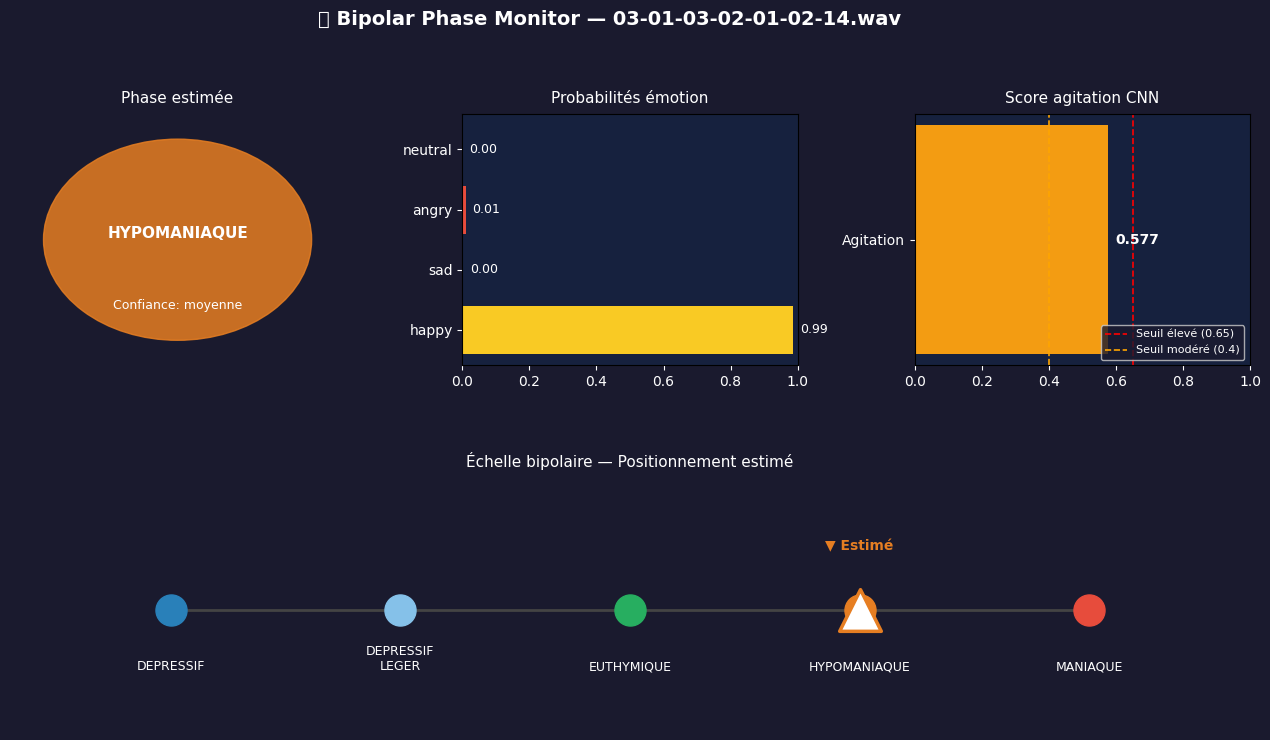

Dashboard → bipolar_dashboard.png


In [53]:
# ============================================================
# 14. TEST SUR UN FICHIER AUDIO
# ============================================================
TEST_FILE = None  # Remplace par ton chemin : "patient.wav"

if TEST_FILE and Path(TEST_FILE).exists():
    report = analyze_bipolar_phase(TEST_FILE, verbose=True)
    if report: plot_bipolar_dashboard(report)
else:
    if fps_tachy:
        demo = random.choice(fps_tachy)
        print(f"Démo sur : {Path(demo).name}")
        report = analyze_bipolar_phase(demo, verbose=True)
        if report: plot_bipolar_dashboard(report)
    else:
        print("Renseigne TEST_FILE avec un chemin .wav")

In [50]:
# ============================================================
# 15. ANALYSE EN LOT — MONITORING LONGITUDINAL
# ============================================================
def batch_monitor(file_paths, patient_id="patient_001"):
    records=[]
    for fp in file_paths:
        r = analyze_bipolar_phase(fp, verbose=False)
        if r is None: continue
        records.append({"patient_id":patient_id,"fichier":r["fichier"],
            "phase":r["phase"],"phase_score":r["phase_score"],
            "confidence":r["confidence"],"emotion":r["emotion"],
            "agitation_score":r["agitation_score"],"tachyphemia":r["tachyphemia_label"],
            "speech_rate":r["speech_rate_syl_s"],"tempo_bpm":r["tempo_bpm"]})
    df = pd.DataFrame(records)
    if not df.empty:
        print("\n=== Résumé monitoring ===")
        print(df["phase"].value_counts())
        print(f"Agitation moyenne : {df['agitation_score'].mean():.3f}")
        print(f"Débit moyen       : {df['speech_rate'].mean():.2f} syl/s")
    return df

sample = random.sample(fps_tachy, min(20, len(fps_tachy)))
df_monitor = batch_monitor(sample, "demo_patient")
df_monitor.head(10)


=== Résumé monitoring ===
phase
HYPOMANIAQUE    12
DEPRESSIF        5
NEUTRE           3
Name: count, dtype: int64
Agitation moyenne : 0.403
Débit moyen       : 0.00 syl/s


,patient_id,fichier,phase,phase_score,confidence,emotion,agitation_score,tachyphemia,speech_rate,tempo_bpm
0,demo_patient,03-01-03-01-02-02-09.wav,NEUTRE,NaN,faible,happy,0.1526,normal,0.0,0.0
1,demo_patient,03-01-04-01-02-01-13.wav,DEPRESSIF,-2.0,moyenne,neutral,0.0139,normal,0.0,0.0
2,demo_patient,03-01-01-01-02-01-09.wav,DEPRESSIF,-2.0,élevée,sad,0.0081,normal,0.0,0.0
3,demo_patient,03-01-08-02-02-01-07.wav,HYPOMANIAQUE,1.0,moyenne,happy,0.5961,tachyphemia,0.0,0.0
4,demo_patient,03-01-08-01-02-02-05.wav,HYPOMANIAQUE,1.0,moyenne,happy,0.5777,tachyphemia,0.0,0.0
5,demo_patient,03-01-08-02-02-02-17.wav,HYPOMANIAQUE,1.0,moyenne,happy,0.5944,tachyphemia,0.0,0.0
6,demo_patient,03-01-03-01-02-02-20.wav,HYPOMANIAQUE,1.0,moyenne,happy,0.5370,tachyphemia,0.0,0.0
7,demo_patient,03-01-05-02-01-02-23.wav,HYPOMANIAQUE,1.0,moyenne,angry,0.5756,tachyphemia,0.0,0.0
8,demo_patient,03-01-05-02-02-01-08.wav,HYPOMANIAQUE,1.0,moyenne,angry,0.5956,tachyphemia,0.0,0.0
9,demo_patient,03-01-08-01-01-02-14.wav,HYPOMANIAQUE,1.0,moyenne,happy,0.5647,tachyphemia,0.0,0.0


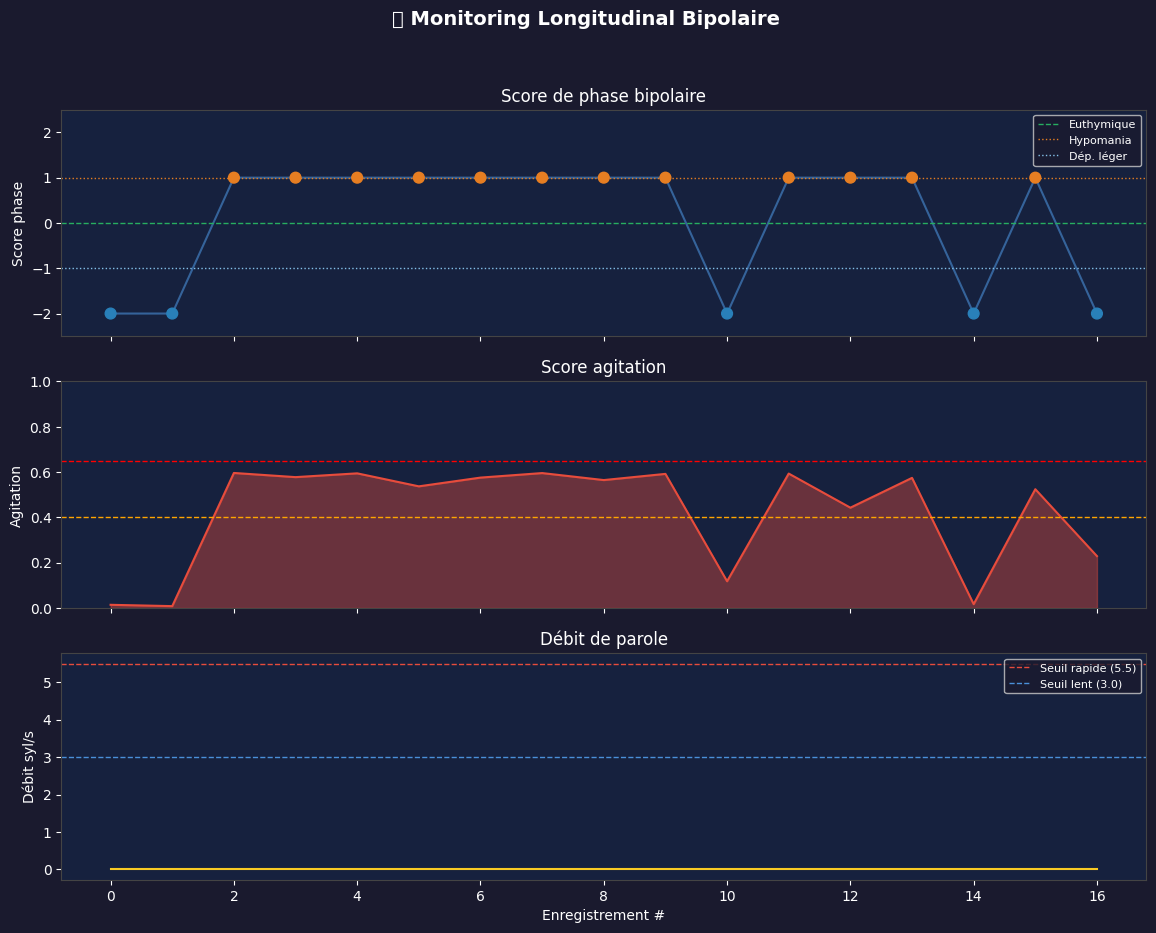

Graphique → bipolar_longitudinal.png


In [51]:
# ============================================================
# 16. VISUALISATION LONGITUDINALE
# ============================================================
def plot_longitudinal(df):
    if df.empty or df["phase_score"].isna().all():
        print("Données insuffisantes."); return
    df2 = df.dropna(subset=["phase_score"]).reset_index(drop=True)
    x   = range(len(df2))

    fig, axes = plt.subplots(3,1,figsize=(14,10),sharex=True); fig.patch.set_facecolor("#1a1a2e")

    # Score de phase
    ax=axes[0]; ax.set_facecolor("#16213e")
    ax.plot(x, df2["phase_score"], color="#4a90d9", lw=1.5, alpha=0.6)
    ax.scatter(x, df2["phase_score"], c=[PHASE_COLORS.get(p,"gray") for p in df2["phase"]], s=60, zorder=4)
    ax.axhline(0, color="#27ae60",ls="--",lw=1,label="Euthymique")
    ax.axhline(1, color="#e67e22",ls=":",lw=1,label="Hypomania")
    ax.axhline(-1,color="#85c1e9",ls=":",lw=1,label="Dép. léger")
    ax.set_ylabel("Score phase",color="white"); ax.set_title("Score de phase bipolaire",color="white")
    ax.legend(fontsize=8,facecolor="#1a1a2e",labelcolor="white"); ax.tick_params(colors="white"); ax.set_ylim(-2.5,2.5)

    # Agitation
    ax2=axes[1]; ax2.set_facecolor("#16213e")
    ax2.fill_between(x,0,df2["agitation_score"],color="#e74c3c",alpha=0.4)
    ax2.plot(x,df2["agitation_score"],color="#e74c3c",lw=1.5)
    ax2.axhline(AGITATION_HIGH,color="red",ls="--",lw=1); ax2.axhline(AGITATION_MODERATE,color="orange",ls="--",lw=1)
    ax2.set_ylabel("Agitation",color="white"); ax2.set_title("Score agitation",color="white")
    ax2.tick_params(colors="white"); ax2.set_ylim(0,1)

    # Débit
    ax3=axes[2]; ax3.set_facecolor("#16213e")
    ax3.plot(x,df2["speech_rate"],color="#f9ca24",lw=1.5)
    ax3.axhline(SPEECH_RATE_FAST,color="#e74c3c",ls="--",lw=1,label=f"Seuil rapide ({SPEECH_RATE_FAST})")
    ax3.axhline(SPEECH_RATE_SLOW,color="#4a90d9",ls="--",lw=1,label=f"Seuil lent ({SPEECH_RATE_SLOW})")
    ax3.set_ylabel("Débit syl/s",color="white"); ax3.set_xlabel("Enregistrement #",color="white")
    ax3.set_title("Débit de parole",color="white")
    ax3.legend(fontsize=8,facecolor="#1a1a2e",labelcolor="white"); ax3.tick_params(colors="white")

    for a in axes:
        for sp in a.spines.values(): sp.set_color("#444")
    plt.suptitle("📈 Monitoring Longitudinal Bipolaire",color="white",fontsize=14,fontweight="bold")
    plt.savefig("bipolar_longitudinal.png",dpi=150,bbox_inches="tight",facecolor=fig.get_facecolor())
    plt.show(); print("Graphique → bipolar_longitudinal.png")

plot_longitudinal(df_monitor)

In [52]:
# ============================================================
# 17. EXPORT CSV
# ============================================================
out = Path("outputs"); out.mkdir(exist_ok=True)
csv_path = out / "bipolar_monitoring_results.csv"
df_monitor.to_csv(csv_path, index=False)
print(f"Résultats exportés : {csv_path}")
print(df_monitor[["fichier","phase","confidence","emotion","agitation_score","speech_rate"]].to_string(index=False))

Résultats exportés : outputs\bipolar_monitoring_results.csv
                 fichier        phase confidence emotion  agitation_score  speech_rate
03-01-03-01-02-02-09.wav       NEUTRE     faible   happy           0.1526          0.0
03-01-04-01-02-01-13.wav    DEPRESSIF    moyenne neutral           0.0139          0.0
03-01-01-01-02-01-09.wav    DEPRESSIF     élevée     sad           0.0081          0.0
03-01-08-02-02-01-07.wav HYPOMANIAQUE    moyenne   happy           0.5961          0.0
03-01-08-01-02-02-05.wav HYPOMANIAQUE    moyenne   happy           0.5777          0.0
03-01-08-02-02-02-17.wav HYPOMANIAQUE    moyenne   happy           0.5944          0.0
03-01-03-01-02-02-20.wav HYPOMANIAQUE    moyenne   happy           0.5370          0.0
03-01-05-02-01-02-23.wav HYPOMANIAQUE    moyenne   angry           0.5756          0.0
03-01-05-02-02-01-08.wav HYPOMANIAQUE    moyenne   angry           0.5956          0.0
03-01-08-01-01-02-14.wav HYPOMANIAQUE    moyenne   happy           0.5

---
## Récapitulatif scientifique — Matrice de fusion finale

| Phase estimée | Tachyphémie | Émotion | Débit | Référence principale |
|---|---|---|---|---|
| **MANIAQUE** | Fort (≥0.65) | angry / happy | > 5.5 syl/s | YMRS item 6 ; Faurholt-Jepsen 2016 |
| **HYPOMANIAQUE** | Modéré–fort | happy / angry / neutral | Accéléré | CALIBER 2024 ; Kaczmarek-Majer 2025 |
| **DEPRESSIF** | Faible ou absent | sad | < 3 syl/s | HAMD item 8 ; Frontiers Neurology 2024 |
| **NEUTRE** | Faible ou absent | neutral | 3–5.5 syl/s | Faurholt-Jepsen 2016 |

> ⚠️ **Avertissement éthique** : Outil de monitoring **NON-DIAGNOSTIQUE**. Ne remplace pas un professionnel de santé.